In [115]:
import os
import copy
import numpy as np
from numpy import random
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms

In [85]:
base_dir = Path("../data/tomatoleaf/tomato")

train_dir = base_dir / "train"
test_dir = base_dir / "val"

print("Train dir:", train_dir.resolve())
print("Test dir:", test_dir.resolve())
print("Train exists:", train_dir.exists())
print("Test exists:", test_dir.exists())

IMG_SIZE = 64 
BATCH_SIZE = 32
DROPOUT_RATE = 0.3
VALIDATION_SIZE = 0.2
SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Train dir: C:\Users\User\Desktop\ML_projekat\data\tomatoleaf\tomato\train
Test dir: C:\Users\User\Desktop\ML_projekat\data\tomatoleaf\tomato\val
Train exists: True
Test exists: True
Device: cpu


In [86]:
def add_windows_long_path_prefix(path):
    """
    Na Windowsu neki fajlovi iz ovog dataset-a imaju jako duga imena.
    Ako je apsolutna putanja duža od Windows MAX_PATH ograničenja, open() moze da prijavi
    FileNotFoundError iako fajl stvarno postoji. Prefiks \\?\ omogucava citanje dugih putanja.
    Na Linuxu/macOS-u funkcija samo vraca obicnu putanju.
    """
    path = Path(path).resolve()
    path_str = str(path)

    if os.name == "nt":
        if path_str.startswith("\\\\"):
            return "\\\\?\\UNC\\" + path_str.lstrip("\\")
        return "\\\\?\\" + path_str

    return path_str


def pil_loader_safe(path):
    """
    Loader za torchvision ImageFolder.
    Koristi Windows long-path prefiks i konvertuje sve slike u RGB.
    """
    with open(add_windows_long_path_prefix(path), "rb") as f:
        image = Image.open(f)
        return image.convert("RGB")


transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [87]:
train_val_dataset = datasets.ImageFolder(
    root=str(train_dir),
    transform=transform,
    loader=pil_loader_safe
)

test_dataset = datasets.ImageFolder(
    root=str(test_dir),
    transform=transform,
    loader=pil_loader_safe
)

class_names = train_val_dataset.classes
num_classes = len(class_names)

print("Klase:", class_names)
print("Broj klasa:", num_classes)
print("Broj slika u originalnom train skupu:", len(train_val_dataset))
print("Broj slika u test skupu:", len(test_dataset))

Klase: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Broj klasa: 10
Broj slika u originalnom train skupu: 10000
Broj slika u test skupu: 1000


In [88]:
val_size = int(len(train_val_dataset) * VALIDATION_SIZE)
train_size = len(train_val_dataset) - val_size

generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 8000
Validation size: 2000
Test size: 1000


In [89]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [90]:
class TripletDataset(Dataset):
    def __init__(self, subset_dataset, transform=None):
        self.dataset = subset_dataset
        self.transform = transform

        # originalni dataset (ImageFolder)
        base_dataset = self.dataset.dataset

        self.class_to_indices = {}

        # samo indeksi iz SUBSET-a
        for subset_idx in range(len(self.dataset)):
            _, label = self.dataset[subset_idx]

            if label not in self.class_to_indices:
                self.class_to_indices[label] = []
            self.class_to_indices[label].append(subset_idx)

        self.labels = list(self.class_to_indices.keys())

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        anchor_img, anchor_label = self.dataset[idx]

        # positive
        positive_idx = idx
        while positive_idx == idx:
            positive_idx = random.choice(self.class_to_indices[anchor_label])

        positive_img, _ = self.dataset[positive_idx]

        # negative
        negative_label = random.choice([l for l in self.labels if l != anchor_label])
        negative_idx = random.choice(self.class_to_indices[negative_label])

        negative_img, _ = self.dataset[negative_idx]

        return anchor_img, positive_img, negative_img, anchor_label

In [91]:
train_triplet_dataset = TripletDataset(train_dataset, transform=None)
val_triplet_dataset = TripletDataset(val_dataset, transform=None)

In [92]:
len(triplet_dataset)

8000

In [93]:
class EmbeddingCNN(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, 3, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, 3, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, 3, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 256, 3, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.embedding = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, embedding_dim)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.embedding(x)
        x = F.normalize(x, p=2, dim=1)
        return x

In [94]:
model = EmbeddingCNN(embedding_dim=128)
model = model.to(device)

Kod metric learning-a nema smisla pratiti tačnost tokom treninga, jer CNN uči embeddinge, a ne direktno klase. Zato ćemo tokom treninga pratiti samo train_loss i val_loss, a klasifikacione metrike ćemo računati kod KNN modela kasnije.

In [130]:
EPOCHS = 10
LEARNING_RATE = 0.001

criterion = nn.TripletMarginLoss(margin=0.3, p=2)  
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_loader = DataLoader(train_triplet_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_triplet_dataset, batch_size=BATCH_SIZE, shuffle=False)

metrics = {
    "train_loss": [],
    "train_steps": [],
    "val_loss": [],
    "val_steps": [],
}

training_step = 0

for epoch in range(EPOCHS):

    model.train()
    
    for anchor, positive, negative, _ in train_loader:

        anchor = anchor.to(device)
        positive = positive.to(device)
        negative = negative.to(device)

        optimizer.zero_grad()

        a = model(anchor)
        p = model(positive)
        n = model(negative)

        loss = criterion(a, p, n)

        loss.backward()
        optimizer.step()

        train_loss = loss.item()
        metrics["train_loss"].append(train_loss)
        metrics["train_steps"].append(training_step)
        training_step += 1

    model.eval()

    total_val_loss = 0
    val_samples = 0

    with torch.no_grad():

        for anchor, positive, negative, _ in val_loader:

            anchor = anchor.to(device)
            positive = positive.to(device)
            negative = negative.to(device)

            a = model(anchor)
            p = model(positive)
            n = model(negative)

            loss = F.triplet_margin_loss(
                a, p, n,
                margin=1.0,
                p=2,
                reduction="sum"
            )

            total_val_loss += loss.item()
            val_samples += anchor.size(0)

    val_loss = total_val_loss / val_samples

    metrics["val_loss"].append(val_loss)
    metrics["val_steps"].append(training_step)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Validation Loss: {val_loss:.4f}")

Epoch 1/10 | Train Loss: 0.0000 | Validation Loss: 0.1692
Epoch 2/10 | Train Loss: 0.0000 | Validation Loss: 0.1637
Epoch 3/10 | Train Loss: 0.0000 | Validation Loss: 0.1770
Epoch 4/10 | Train Loss: 0.0000 | Validation Loss: 0.1635
Epoch 5/10 | Train Loss: 0.0000 | Validation Loss: 0.1405
Epoch 6/10 | Train Loss: 0.0049 | Validation Loss: 0.1663
Epoch 7/10 | Train Loss: 0.0000 | Validation Loss: 0.1466
Epoch 8/10 | Train Loss: 0.0000 | Validation Loss: 0.1457
Epoch 9/10 | Train Loss: 0.0000 | Validation Loss: 0.1641
Epoch 10/10 | Train Loss: 0.0000 | Validation Loss: 0.1565


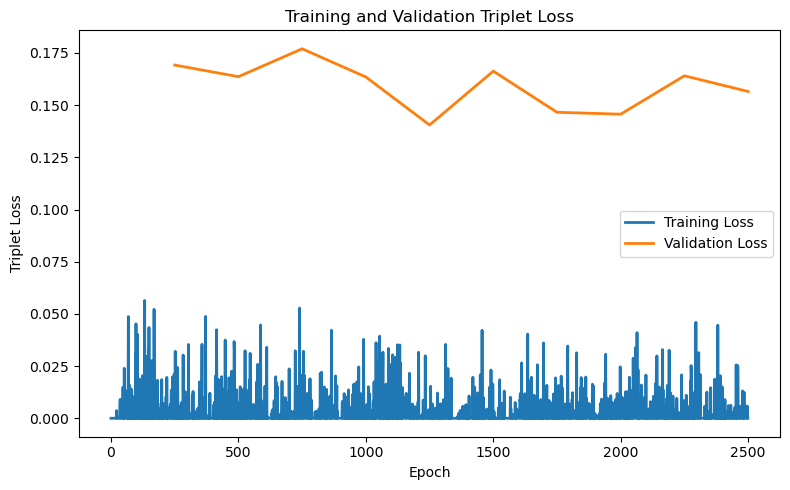

In [131]:
plt.figure(figsize=(8, 5))

plt.title('Training and Validation Triplet Loss')
plt.xlabel('Epoch')
plt.ylabel('Triplet Loss')

plt.plot(metrics['train_steps'], metrics['train_loss'], linewidth=2, label='Training Loss')
plt.plot(metrics['val_steps'], metrics['val_loss'], linewidth=2, label='Validation Loss')

plt.legend()

plt.tight_layout()
plt.show()

In [105]:
def extract_embeddings(model, loader, device):
    model.eval()

    embeddings = []
    labels = []

    with torch.no_grad():
        for anchor, positive, negative, label in loader:
            anchor = anchor.to(device)

            emb = model(anchor)   # koristi anchor kao reprezentaciju

            embeddings.append(emb.cpu().numpy())
            labels.append(label.numpy())

    embeddings = np.vstack(embeddings)
    labels = np.concatenate(labels)

    return embeddings, labels

Test dataset ne treba da vraća triplete, jer to nema smisla za evaluaciju.

Naime, u treningu i validaciji koristimo triplete i kao izlaz CNN-a dobijamo embedding-e (umesto klase kod običnog CNN-a), odnosno nove reprezentacije slika, a pri 
evaluaciji modela koristimo normalne slike, odnosno koristimo njihovu standardnu reprezentaciju, pa ćemo napraviti i funkciju koja
ekstraktuje takve slike.

In [108]:
def extract_embeddings_standard(model, loader, device):
    model.eval()

    embeddings = []
    labels = []

    with torch.no_grad():
        for images, label in loader:
            images = images.to(device)

            emb = model(images)

            embeddings.append(emb.cpu().numpy())
            labels.append(label.numpy())

    embeddings = np.vstack(embeddings)
    labels = np.concatenate(labels)

    return embeddings, labels

In [123]:
train_emb, train_labels = extract_embeddings(model, train_loader, device)
val_emb, val_labels = extract_embeddings(model, val_loader, device)
test_emb, test_labels = extract_embeddings_standard(model, test_loader, device)

In [124]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(train_emb, train_labels)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None
